In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from geodesic_toolbox import *
from functools import partial
from sklearn.datasets import make_swiss_roll
from utils import *

# 2D Dummy data

In [2]:
device = "cuda"

In [3]:
def get_bounds(embeddings: torch.Tensor, margin: float = 0.0) -> torch.Tensor:
    """
    Compute the bounds of the embeddings.

    Parameters:
    ----------
    embeddings : torch.Tensor (n_points, 2)
        The embeddings of the points.
    margin : float
        Margin scaling factor to add to the bounds. (default is 0)
        This is useful to avoid points being too close to the edges of the plot.

    Returns:
    -------
    torch.Tensor (4,)
        [min_x, max_x, min_y, max_y], the bounds of the embeddings.
    """
    min_x, max_x = embeddings[:, 0].min(), embeddings[:, 0].max()
    min_y, max_y = embeddings[:, 1].min(), embeddings[:, 1].max()
    # Add margin to the bounds
    min_x -= margin * (max_x - min_x)
    max_x += margin * (max_x - min_x)
    min_y -= margin * (max_y - min_y)
    max_y += margin * (max_y - min_y)
    # Ensure the bounds are in the correct order
    min_x, max_x = min(min_x, max_x), max(min_x, max_x)
    min_y, max_y = min(min_y, max_y), max(min_y, max_y)
    # Create a tensor with the bounds
    bounds = [min_x, max_x, min_y, max_y]
    bounds = torch.tensor(bounds)
    return bounds

def get_spiral(n_pts: int, freq: float, sigma: float = 0.1, t_max: float = 4 * np.pi):
    # Sample uniformly in arc length on the noiseless spiral, then add noise.
    t_dense = np.linspace(0.0, t_max, max(5000, 10 * n_pts))
    speed = np.sqrt(1.0 + (freq * t_dense) ** 2)
    ds = 0.5 * (speed[1:] + speed[:-1]) * np.diff(t_dense)
    s_dense = np.concatenate(([0.0], np.cumsum(ds)))
    s_uniform = np.linspace(0.0, s_dense[-1], n_pts)
    t = np.interp(s_uniform, s_dense, t_dense)

    x = t * np.cos(freq * t) + np.random.normal(0, sigma, n_pts)
    y = t * np.sin(freq * t) + np.random.normal(0, sigma, n_pts)
    X = np.stack([x, y], axis=1)

    # Normalize the data
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    s = s_uniform / s_uniform[-1]
    X = torch.from_numpy(X).double().to(device)
    s = torch.from_numpy(s).double().to(device)
    return X, s


def get_x_plt(resolution: int, bounds: tuple = (-2, 2, -2, 2)):
    x = np.linspace(bounds[0], bounds[1], resolution)
    y = np.linspace(bounds[2], bounds[3], resolution)
    xx, yy = np.meshgrid(x, y)
    X_plt = np.stack([xx.flatten(), yy.flatten()], axis=1)
    return torch.from_numpy(X_plt).float().to(device)


def spiral_omega(z: torch.Tensor, freq: float) -> torch.Tensor:
    """
    Compute the omega vector field for a spiral.

    Parameters:
    ----------
    z : torch.Tensor (n_points, 2)
        The input points in 2D space.
    freq : float
        The frequency of the spiral.

    Returns:
    -------
    torch.Tensor (n_points, 2)
        The omega vector field at the input points.
    """
    x = z[:, 0]
    y = z[:, 1]
    t = torch.sqrt(x**2 + y**2)
    omega_x = -freq * y / (t + 1e-8)  # Avoid division by zero
    omega_y = freq * x / (t + 1e-8)   # Avoid division by zero
    omega = torch.stack([omega_x, omega_y], dim=1)
    return omega / torch.norm(omega, dim=1, keepdim=True)  # Normalize the vector field




In [4]:
class CometricSpiral(torch.nn.Module):
    def __init__(self, cometric:CoMetric, freq: float = 1.0):
        super().__init__()
        self.cometric = cometric
        self.freq = freq

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        omega = spiral_omega(z, freq=self.freq)
        norm_omega = self.cometric.cometric(z, omega)
        omega = omega / (norm_omega.unsqueeze(1) + 1e-8)  # Avoid division by zero
        return omega

In [5]:
X, t = get_spiral(3000, freq=1.0, sigma=0.5)
X = X.to(device)
base_cometric = CentroidsCometric(X, IdentityCoMetric()(X)).to(device)

omega_spiral_ = partial(spiral_omega, freq=1.0)
omega_X = omega_spiral_(X)
bounds = get_bounds(X, margin=0.2)


Computing magnification factor: 100%|██████████| 79/79 [00:00<00:00, 1515.39batch/s]


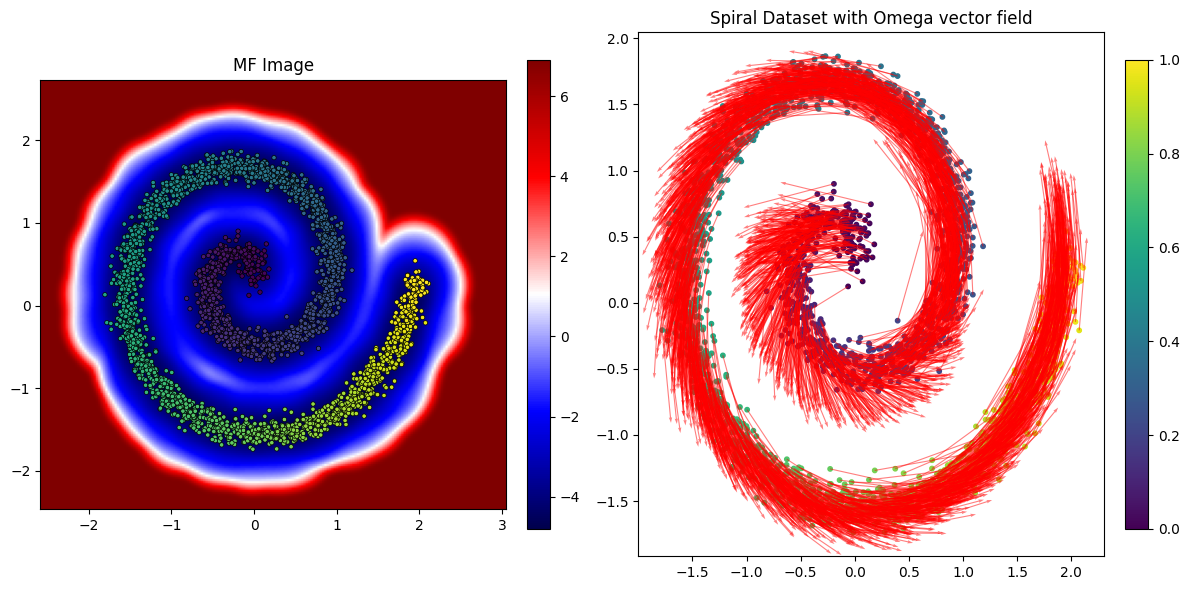

In [6]:
mf = get_mf_image(base_cometric, X, bounds)


fig, axes = plt.subplots(1,2, figsize=(12, 6))
im = axes[0].imshow(mf.cpu().numpy(), cmap="seismic", origin="lower", extent=bounds)
t_cbar = axes[0].scatter(
    X[:, 0].cpu(), X[:, 1].cpu(), c=t.cpu(), cmap="viridis", s=10, edgecolor="k", linewidth=0.5
)
axes[0].set_title("MF Image")
axes[1].scatter(X[:, 0].cpu(), X[:, 1].cpu(), c=t.cpu(), cmap="viridis", s=10)
axes[1].quiver(X[::, 0].cpu(), X[::, 1].cpu(), omega_X[::, 0].cpu(), omega_X[::, 1].cpu(), color='red', alpha=0.5, scale=5, angles='xy')
axes[1].set_title("Spiral Dataset with Omega vector field")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(t_cbar, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.tight_layout()
plt.show()

In [7]:
omega_true = CometricSpiral(base_cometric, freq=1.0)

randers_metric = RandersMetrics(
    base_cometric=base_cometric,
    omega=omega_true,
    beta=0.5
)

In [8]:
solver_r = SolverGraph(cometric=base_cometric,
                       data=X,
                       n_neighbors=8,
                       )
solver_f = SolverGraphFinsler(finsler_metric=randers_metric,
                            data=X,
                            n_neighbors=8,
                            )

Initialize Graph: 100%|██████████| 47/47 [00:05<00:00,  8.87batch/s]


Computing predecessors...
Done.


Initialize Graph: 100%|██████████| 47/47 [00:13<00:00,  3.44batch/s]


Computing predecessors...
Done.


In [9]:
W = solver_f.W
valid_edges_plt = W > 0
valid_edges = valid_edges_plt.nonzero(as_tuple=False)

epsilon = find_espilon(W)*2
K = torch.exp(-W / epsilon)


In [10]:
import torch


def local_poly_gradient(x: torch.Tensor, X: torch.Tensor, f0: torch.Tensor, F: torch.Tensor):
    """
    Batched local quadratic polynomial reconstruction. We assume that the local polynomial is of the form
    f(x + dx) = f(x) + a^T dx + 1/2 dx^T H dx, where a is the gradient and H is the Hessian. We want to solve for a and H given the values of f at the center point x and its neighbors X. We use least-squares to solve for the coefficients of the polynomial, and then extract the gradient from the coefficients.

    Parameters
    ----------
    x : torch.Tensor (B, D)
        Center points.
    X : torch.Tensor (B, M, D)
        Neighbor points for each center.
    f0 : torch.Tensor (B, N)
        Values of N functions at each center.
    F : torch.Tensor (B, M, N)
        Values of N functions at each neighbor.

    Returns
    -------
    grad : torch.Tensor (B, N, D)
        grad[b, k, d] = ∂f_k / ∂x_d at center b.
    """

    B, M, D = X.shape

    assert x.shape == (B, D)
    assert f0.ndim == 2
    assert F.shape == (B, M, f0.shape[1])

    # Shift coordinates
    dx = X - x[:, None, :] # (B, M, D)

    ij = torch.triu_indices(
        D,
        D,
        device=X.device,
    )
    quadratic = dx[:, :, ij[0]] * dx[:, :, ij[1]] # x^i x^j

    # For diagonal terms: 1/2 H_jj dx_j²
    # For off-diagonal terms: H_jk dx_j dx_k
    diagonal = ij[0] == ij[1]
    quadratic = torch.where(
        diagonal[None, None, :],
        0.5 * quadratic,
        quadratic,
    )

    # Design matrix
    A = torch.cat(
        [dx, quadratic],
        dim=-1,
    ) # (B, M, D + D(D+1)/2)

    rhs = F - f0[:, None, :]# (B, M, N)

    sol = torch.linalg.lstsq(A, rhs).solution
    grad = sol[:, :D, :].transpose(1, 2) # (B, N, D)

    return grad

In [11]:
class OmegaModel(torch.nn.Module):
    """Vector field model for the omega vector field in Randers metrics. This model takes in 2D coordinates and outputs a 2D vector field.
    It also enforces ||omega||_2 < 1 by first normalizing 
    """
    def __init__(self, d:int, hidden_dims:list[int]=[64, 64]):
        super().__init__()
        layers = []
        input_dim = d
        for hidden_dim in hidden_dims:
            layers.append(torch.nn.Linear(input_dim, hidden_dim))
            layers.append(torch.nn.GELU())
            input_dim = hidden_dim
        layers.append(torch.nn.Linear(input_dim, d))
        self.model = torch.nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        omega = self.model(x)
        # Enforce ||omega||_2 < 1
        omega_norm = torch.norm(omega, dim=1, keepdim=True)
        omega = omega / (omega_norm + 1e-8)  # Avoid division by zero
        return omega_norm.sigmoid() * omega  # Scale by sigmoid to ensure ||omega|| < 1

In [12]:
omega_model = OmegaModel(d=2, hidden_dims=[64, 64]).to(device)
randers = RandersMetrics(base_cometric=IdentityCoMetric(), omega=omega_model, beta=0.5)

In [13]:
# We build the gradient of phi_i with respect to X_i using local polynomial reconstruction
# TODO: precompute this for all points and store it in a tensor to avoid recomputing it every time
def compute_grad_phi_i(X, idx_i, valid_edges, eig_vecs):
    grad_phi_i = torch.zeros(X_i.shape[0], eig_vecs.shape[1], X_i.shape[1], device=device)
    for idx in idx_i:
        neighbors = valid_edges[valid_edges[:, 0] == idx.cpu()][:, 1]
        x_i = X[idx]
        x_i_neighbors = X[neighbors]
        f0 = eig_vecs[idx, :]
        F = eig_vecs[neighbors, :]

        grad_phi_i_ = local_poly_gradient(
            x=x_i.unsqueeze(0).to(torch.float32),
            X=x_i_neighbors.unsqueeze(0).to(torch.float32),
            f0=f0.unsqueeze(0).to(torch.float32),
            F=F.unsqueeze(0).to(torch.float32)
        )[0] # (N, D)
        grad_phi_i[idx == idx_i] = grad_phi_i_
    return grad_phi_i

def reconstruction_loss(X_i, phi_i, lambda_i, grad_phi_i, randers, mu0, mu1):
    # Randers related quantities
    b_i = randers.beta * randers.omega(X_i.to(torch.float32)) # (B, D)
    b_i = b_i[:,None,:].repeat(1, grad_phi_i.shape[1], 1) # (B, N, D)
    b_i_norm_sqr = torch.norm(b_i, dim=-1)**2
    grad_b_i_norm_sqr = torch.autograd.grad(b_i_norm_sqr.sum(), X_i, create_graph=True)[0]

    m = b_i.shape[0]
    const = mu1/mu0 * (m+1)/m

    denom = 1 - b_i_norm_sqr # (B, N)
    fst_term = const * b_i / denom[:,:,None] # (B, N, D)

    lhs = (m+1)/2 * grad_b_i_norm_sqr[:,None,:] / denom[:,:,None] # (B, N, D)
    lhs -= grad_phi_i

    reco = -torch.einsum("bnd,bnd->bn", lhs.to(torch.float32), fst_term.to(torch.float32))

    loss = lambda_i[:,None].to(torch.float32) * phi_i.to(torch.float32) - reco
    loss = loss.pow(2).mean()
    return loss

# Dummy eigenvalues
eig_vals = torch.randn(K.shape[0], device=device) # (N,)
# Dummy eigenvectors
eig_vecs = torch.randn(K.shape[0], K.shape[0], device=device) # (N, N)
# Dummy values for mu0 and mu1
mu0,mu1 = 1.0,1.0

# Dummy batch
B = 3
idx_i = torch.randint(0, X.shape[0], (B,), device=device)


X_i = X[idx_i].requires_grad_(True)
phi_i = eig_vecs[idx_i, :]
lambda_i = eig_vals[idx_i]
grad_phi_i = compute_grad_phi_i(X, idx_i, valid_edges, eig_vecs) # (B, N, D)

loss = reconstruction_loss(X_i, phi_i, lambda_i, grad_phi_i, randers, mu0, mu1)